# Customer Churn Prediction
### Telecom Customer Retention — End-to-End ML Pipeline

**Business Problem** — A telecom company loses ~26 % of customers annually. Retaining an existing customer costs 5–25× less than acquiring a new one. The retention team needs to know *who* will churn, *why*, and with enough lead time to intervene.

**Objective**
1. Identify at-risk customers with high recall (catch as many churners as possible)
2. Explain *why* each customer is flagged (SHAP values)
3. Find the decision threshold that minimises total business cost

**Dataset** — IBM Telco Customer Churn · 7,043 rows · 19 predictors · binary target (`Churn: Yes/No`)

**Metric priority**: ROC-AUC → Recall → F2 Score

## Section 1: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Preprocessing & pipelines ──────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RandomizedSearchCV,
                                     GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# ── Classifiers ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, VotingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# ── Metrics ────────────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              confusion_matrix, classification_report, roc_curve)

# ── Imbalanced-learn & persistence ────────────────────────────────────────
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

# ── Plot defaults ─────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

print("All libraries loaded ✓")

All libraries loaded ✓


## Section 2: Data Loading & Quality Audit

In [2]:
df = pd.read_csv("Churn.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts().to_string()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.head()

Shape: 7,043 rows × 21 columns

Column dtypes:
object     18
int64       2
float64     1

Duplicate rows: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Clean & validate ──────────────────────────────────────────────────────
# 1. Strip whitespace from all string columns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 2. Drop customerID — not a predictor
df.drop(columns=["customerID"], inplace=True)

# 3. TotalCharges is stored as object in raw data; coerce to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_missing = df["TotalCharges"].isna().sum()
print(f"TotalCharges: {n_missing} nulls found (new customers with zero tenure) → filled with median")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 4. Encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(f"\nFinal shape: {df.shape}")
print(f"\nNull values remaining:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nData quality check passed ✓")

TotalCharges: 11 nulls found (new customers with zero tenure) → filled with median

Final shape: (7043, 20)

Null values remaining:
Series([], dtype: int64)

Data quality check passed ✓


In [4]:
# ── Statistical summary ───────────────────────────────────────────────────
print("Numerical features — descriptive statistics")
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

Numerical features — descriptive statistics


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## Section 3: Exploratory Data Analysis

We explore three questions:
1. How imbalanced is the target?
2. Which numerical features separate churners from retained customers?
3. Which categorical features have the highest churn rates?

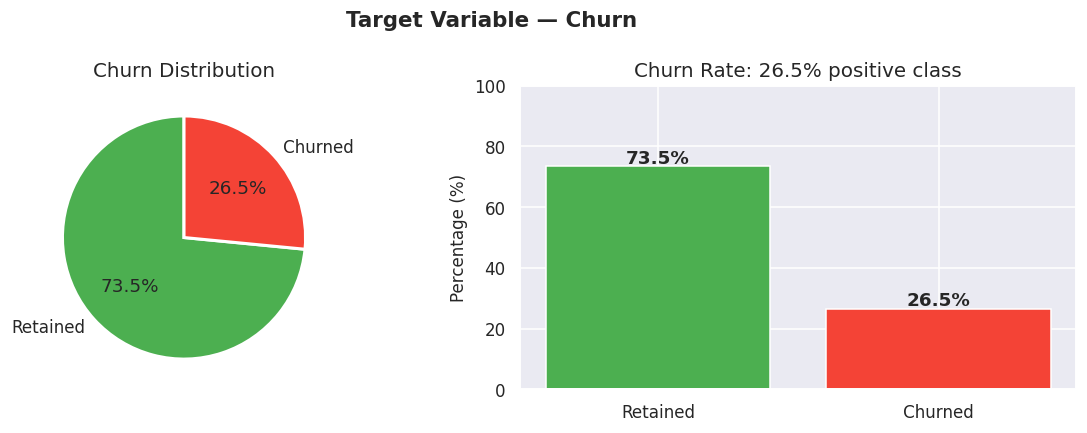

Class imbalance ratio: 2.8:1 (retained:churned)
→ Moderate imbalance — SMOTE will be applied in Section 7


In [5]:
# ── 3.1  Target distribution ──────────────────────────────────────────────
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(churn_counts, labels=["Retained", "Churned"],
            autopct="%1.1f%%", startangle=90,
            colors=["#4CAF50", "#F44336"],
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Churn Distribution")

axes[1].bar(["Retained", "Churned"], churn_pct,
            color=["#4CAF50", "#F44336"], edgecolor="white")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Churn Rate: {:.1f}% positive class".format(churn_pct[1]))
axes[1].set_ylim(0, 100)
for i, v in enumerate(churn_pct):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Target Variable — Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1 (retained:churned)")
print("→ Moderate imbalance — SMOTE will be applied in Section 7")

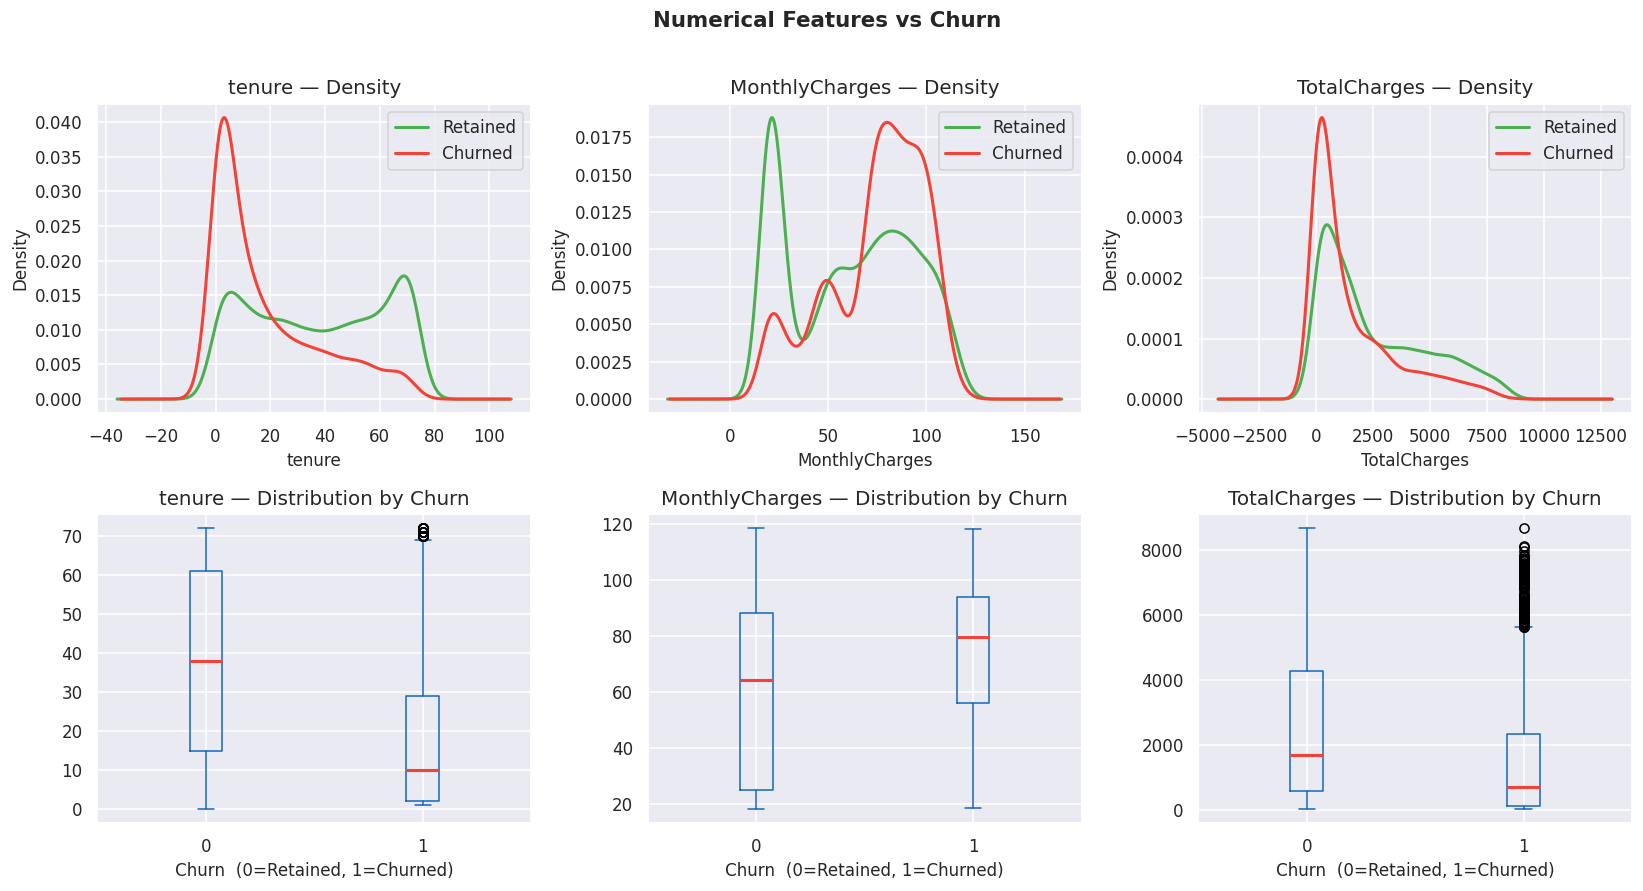

Median values by churn status:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
Retained    38.0            64.4        1679.5
Churned     10.0            79.6         703.6


In [6]:
# ── 3.2  Numerical features vs Churn ──────────────────────────────────────
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(num_cols):
    # KDE plot
    ax = axes[0, idx]
    df[df["Churn"] == 0][col].plot.kde(ax=ax, color="#4CAF50", label="Retained", linewidth=2)
    df[df["Churn"] == 1][col].plot.kde(ax=ax, color="#F44336", label="Churned",  linewidth=2)
    ax.set_title(f"{col} — Density")
    ax.legend()
    ax.set_xlabel(col)

    # Box plot
    ax = axes[1, idx]
    df.boxplot(column=col, by="Churn", ax=ax,
               boxprops=dict(color="#1565C0"),
               medianprops=dict(color="#F44336", linewidth=2),
               whiskerprops=dict(color="#1565C0"),
               capprops=dict(color="#1565C0"))
    ax.set_title(f"{col} — Distribution by Churn")
    ax.set_xlabel("Churn  (0=Retained, 1=Churned)")

plt.suptitle("Numerical Features vs Churn", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print median comparison
print("Median values by churn status:")
print(df.groupby("Churn")[num_cols].median().round(1).rename(index={0:"Retained",1:"Churned"}).to_string())

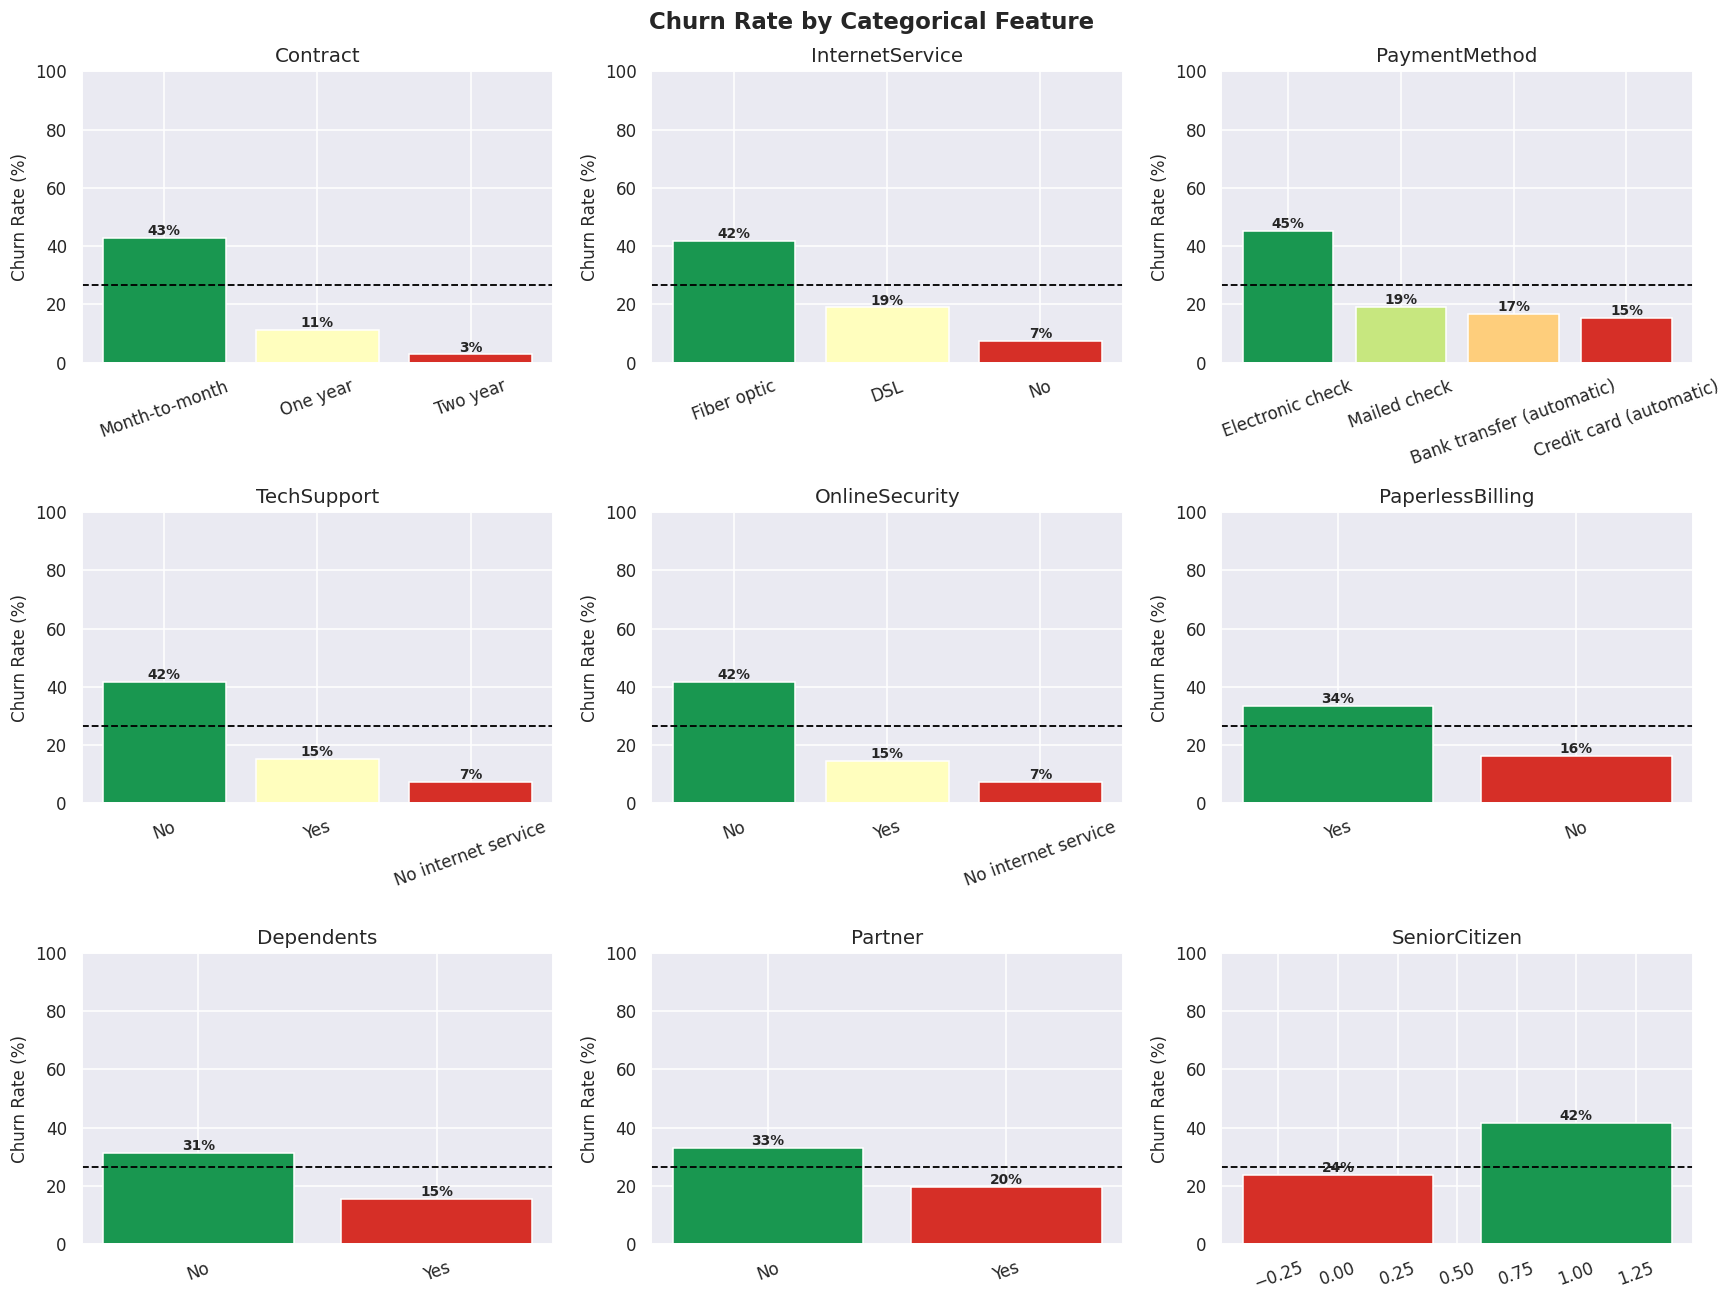

In [7]:
# ── 3.3  Churn rate by key categorical features ───────────────────────────
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity", "PaperlessBilling",
            "Dependents", "Partner", "SeniorCitizen"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    bars = axes[idx].bar(churn_rate.index, churn_rate.values,
                         color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(churn_rate))),
                         edgecolor="white")
    axes[idx].axhline(df["Churn"].mean() * 100, color="black",
                       linestyle="--", linewidth=1.2, label="Overall avg")
    axes[idx].set_title(col)
    axes[idx].set_ylabel("Churn Rate (%)")
    axes[idx].set_ylim(0, 100)
    axes[idx].tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, val + 1,
                       f"{val:.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Churn Rate by Categorical Feature", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

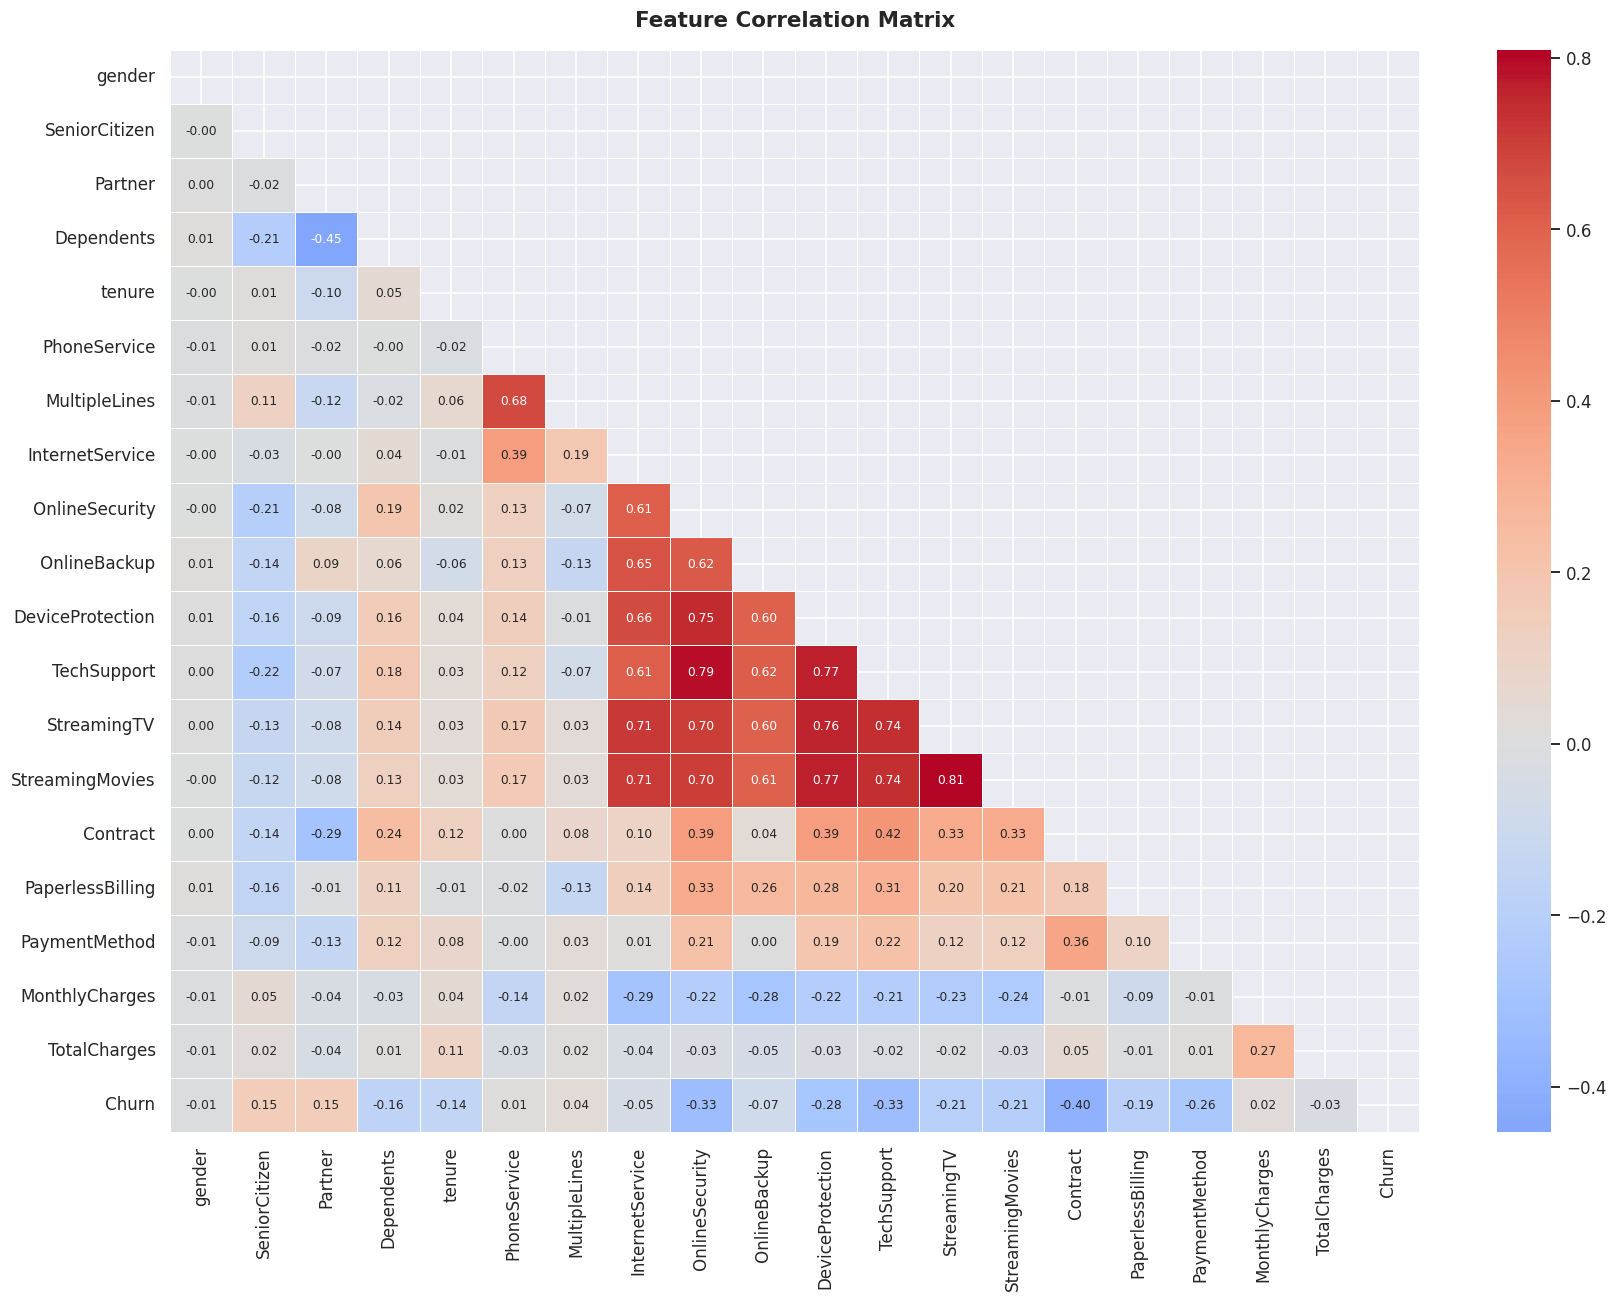

In [8]:
# ── 3.4  Correlation heatmap ──────────────────────────────────────────────
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            annot_kws={"size": 8})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### Key EDA Insights

| Feature | Finding | Retention Action |
|---|---|---|
| **Contract type** | Month-to-month → ~43% churn · Two-year → ~3% churn | Offer annual plan incentives |
| **Tenure** | Churners median tenure ~10 mo vs 38 mo for retained | Early-life engagement programme |
| **Monthly Charges** | Churners pay ~$15/mo more on average | Targeted discount for high-charge segments |
| **Internet Service** | Fiber optic ~42% churn vs DSL ~19% | Investigate service quality issues |
| **Tech Support / Online Security** | Absence → ~2× churn rate | Bundle upsell to retain |
| **Payment Method** | Electronic check → highest churn (~45%) | Auto-pay migration campaign |
| **Senior Citizen** | Seniors churn ~42% vs 24% overall | Dedicated senior support plan |

## Section 4: Feature Engineering & Preprocessing Pipeline

We use a `ColumnTransformer` to apply different transformations per feature type — this is the **production-safe** approach since the same pipeline is used for training, evaluation, and serving.

| Feature Group | Columns | Transformer |
|---|---|---|
| Numerical (3) | tenure, MonthlyCharges, TotalCharges | StandardScaler |
| Binary categorical (5) | gender, Partner, Dependents, PhoneService, PaperlessBilling | OrdinalEncoder |
| Multi-class categorical (10) | Contract, InternetService, PaymentMethod, … | OneHotEncoder(drop=first) |

In [9]:
# ── Feature groups ────────────────────────────────────────────────────────
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_binary = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

cat_ohe = ["MultipleLines", "InternetService", "OnlineSecurity",
           "OnlineBackup", "DeviceProtection", "TechSupport",
           "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# ── ColumnTransformer ─────────────────────────────────────────────────────
numeric_pipe = Pipeline([("scaler", StandardScaler())])
binary_pipe  = Pipeline([("enc",    OrdinalEncoder())])
ohe_pipe     = Pipeline([("enc",    OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_features),
    ("bin", binary_pipe,  cat_binary),
    ("ohe", ohe_pipe,     cat_ohe),
], remainder="drop")

# ── Train / Test split ────────────────────────────────────────────────────
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Verify
X_train_t = preprocessor.fit_transform(X_train)
print(f"Training set  : {X_train.shape[0]:,} rows | {X_train_t.shape[1]} features after encoding")
print(f"Test set      : {X_test.shape[0]:,} rows")
print(f"Churn rate    : train={y_train.mean()*100:.1f}%  test={y_test.mean()*100:.1f}%  (stratified ✓)")

Training set  : 5,634 rows | 29 features after encoding
Test set      : 1,409 rows
Churn rate    : train=26.5%  test=26.5%  (stratified ✓)


## Section 5: Baseline Model Screening

We evaluate 10 classifiers using **Stratified 10-fold CV** on the training set. Each classifier is wrapped in a `Pipeline` with the same `ColumnTransformer` preprocessor — no data leakage.

In [10]:
# ── Define 10 models ──────────────────────────────────────────────────────
def make_pipe(clf):
    return Pipeline([("preprocess", preprocessor), ("model", clf)])

MODELS = {
    "Logistic Regression" : make_pipe(LogisticRegression(max_iter=1000, random_state=42)),
    "SVM (Linear)"        : make_pipe(SVC(kernel="linear", probability=True, random_state=42)),
    "Kernel SVM"          : make_pipe(SVC(kernel="rbf",    probability=True, random_state=42)),
    "KNN"                 : make_pipe(KNeighborsClassifier(n_neighbors=22)),
    "Naive Bayes"         : make_pipe(GaussianNB()),
    "Decision Tree"       : make_pipe(DecisionTreeClassifier(criterion="entropy", random_state=42)),
    "Random Forest"       : make_pipe(RandomForestClassifier(n_estimators=100, random_state=42)),
    "AdaBoost"            : make_pipe(AdaBoostClassifier(random_state=42)),
    "Gradient Boosting"   : make_pipe(GradientBoostingClassifier(random_state=42)),
    "Voting Classifier"   : make_pipe(VotingClassifier(estimators=[
                                ("gb",  GradientBoostingClassifier(random_state=42)),
                                ("lr",  LogisticRegression(max_iter=1000)),
                                ("ada", AdaBoostClassifier(random_state=42)),
                            ], voting="soft")),
}

# ── Stratified 10-fold CV ──────────────────────────────────────────────────
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

print("Running cross-validation (this takes ~3-4 minutes)…\n")
for name, pipe in MODELS.items():
    auc  = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="roc_auc",  n_jobs=-1)
    acc  = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="accuracy", n_jobs=-1)
    results.append({
        "Model"      : name,
        "ROC-AUC"    : auc.mean(),
        "AUC Std"    : auc.std(),
        "Accuracy"   : acc.mean(),
        "Acc Std"    : acc.std(),
    })
    print(f"  {name:<25} ROC-AUC={auc.mean():.4f} ± {auc.std():.4f}")

cv_results = (pd.DataFrame(results)
                .sort_values("ROC-AUC", ascending=False)
                .reset_index(drop=True))
cv_results.round(4)

Running cross-validation (this takes ~3-4 minutes)…

  Logistic Regression       ROC-AUC=0.8458 ± 0.0151
  SVM (Linear)              ROC-AUC=0.8328 ± 0.0161
  Kernel SVM                ROC-AUC=0.7979 ± 0.0191
  KNN                       ROC-AUC=0.8282 ± 0.0137
  Naive Bayes               ROC-AUC=0.8228 ± 0.0154
  Decision Tree             ROC-AUC=0.6737 ± 0.0148
  Random Forest             ROC-AUC=0.8226 ± 0.0160
  AdaBoost                  ROC-AUC=0.8438 ± 0.0169
  Gradient Boosting         ROC-AUC=0.8476 ± 0.0152
  Voting Classifier         ROC-AUC=0.8498 ± 0.0156


,Model,ROC-AUC,AUC Std,Accuracy,Acc Std
0,Voting Classifier,0.8498,0.0156,0.8055,0.0125
1,Gradient Boosting,0.8476,0.0152,0.8021,0.0119
2,Logistic Regression,0.8458,0.0151,0.8037,0.0150
3,AdaBoost,0.8438,0.0169,0.8037,0.0094
4,SVM (Linear),0.8328,0.0161,0.7989,0.0137
5,KNN,0.8282,0.0137,0.7932,0.0109
6,Naive Bayes,0.8228,0.0154,0.6626,0.0186
7,Random Forest,0.8226,0.0160,0.7847,0.0123
8,Kernel SVM,0.7979,0.0191,0.8048,0.0105
9,Decision Tree,0.6737,0.0148,0.7441,0.0144


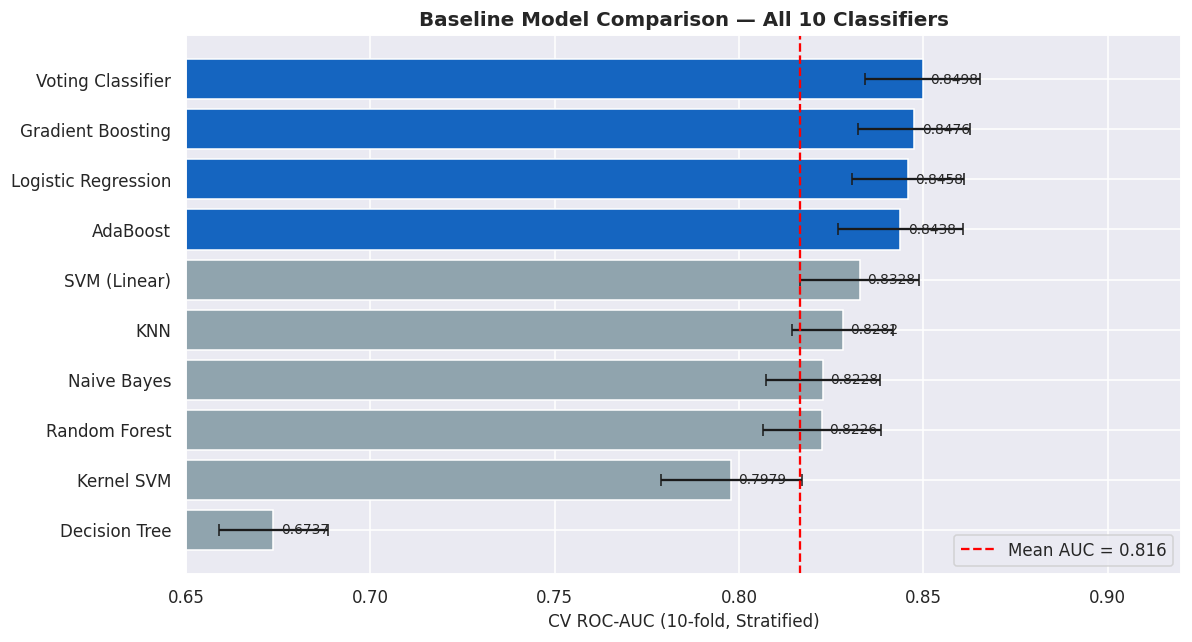


Top 4 selected for hyperparameter tuning: ['Voting Classifier', 'Gradient Boosting', 'Logistic Regression', 'AdaBoost']


In [11]:
# ── Visualise model comparison ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#1565C0" if i < 4 else "#90A4AE" for i in range(len(cv_results))]
bars = ax.barh(cv_results["Model"][::-1], cv_results["ROC-AUC"][::-1],
               xerr=cv_results["AUC Std"][::-1], color=colors[::-1],
               edgecolor="white", capsize=4)

ax.axvline(cv_results["ROC-AUC"].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"Mean AUC = {cv_results['ROC-AUC'].mean():.3f}")
ax.set_xlabel("CV ROC-AUC (10-fold, Stratified)")
ax.set_title("Baseline Model Comparison — All 10 Classifiers", fontweight="bold")
ax.legend()
ax.set_xlim(0.65, 0.92)

for bar, val in zip(bars, cv_results["ROC-AUC"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

top4 = cv_results.head(4)["Model"].tolist()
print(f"\nTop 4 selected for hyperparameter tuning: {top4}")

## Section 6: Hyperparameter Tuning

We tune the top 4 models using **RandomizedSearchCV** (faster than grid search, covers more of the hyperparameter space). Scoring: `roc_auc` with 5-fold CV.

In [12]:
# ── Base pipelines for tuning ─────────────────────────────────────────────
ada_pipeline = Pipeline([("preprocess", preprocessor),
                          ("model", AdaBoostClassifier(random_state=42))])

gb_pipeline  = Pipeline([("preprocess", preprocessor),
                          ("model", GradientBoostingClassifier(random_state=42))])

log_pipeline = Pipeline([("preprocess", preprocessor),
                          ("model", LogisticRegression(max_iter=1000, solver="liblinear"))])

voting_pipeline = Pipeline([("preprocess", preprocessor),
                             ("model", VotingClassifier(estimators=[
                                 ("gb",  GradientBoostingClassifier(random_state=42)),
                                 ("lr",  LogisticRegression(max_iter=1000)),
                                 ("ada", AdaBoostClassifier(random_state=42)),
                             ], voting="soft"))])

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── AdaBoost ──────────────────────────────────────────────────────────────
ada_rs = RandomizedSearchCV(ada_pipeline,
    param_distributions={"model__n_estimators": [50,100,150,200,300],
                         "model__learning_rate": [0.01,0.05,0.1,0.3,0.5,1.0]},
    n_iter=12, scoring="roc_auc", cv=CV5, n_jobs=-1, random_state=42, verbose=0)
ada_rs.fit(X_train, y_train)
ada_best = ada_rs.best_estimator_
print(f"AdaBoost       best ROC-AUC: {ada_rs.best_score_:.4f}  params: {ada_rs.best_params_}")

# ── Gradient Boosting ──────────────────────────────────────────────────────
gb_rs = RandomizedSearchCV(gb_pipeline,
    param_distributions={"model__n_estimators": [100,200,300],
                         "model__learning_rate": [0.01,0.05,0.1,0.2],
                         "model__max_depth": [1,2,3]},
    n_iter=12, scoring="roc_auc", cv=CV5, n_jobs=-1, random_state=42, verbose=0)
gb_rs.fit(X_train, y_train)
gb_best = gb_rs.best_estimator_
print(f"GradientBoosting best ROC-AUC: {gb_rs.best_score_:.4f}  params: {gb_rs.best_params_}")

# ── Logistic Regression ────────────────────────────────────────────────────
log_rs = RandomizedSearchCV(log_pipeline,
    param_distributions={"model__C": [0.01,0.1,1,10,100],
                         "model__penalty": ["l1","l2"],
                         "model__class_weight": [None,"balanced"]},
    n_iter=10, scoring="roc_auc", cv=CV5, n_jobs=-1, random_state=42, verbose=0)
log_rs.fit(X_train, y_train)
log_best = log_rs.best_estimator_
print(f"LogisticRegression best ROC-AUC: {log_rs.best_score_:.4f}  params: {log_rs.best_params_}")

AdaBoost       best ROC-AUC: 0.8486  params: {'model__n_estimators': 200, 'model__learning_rate': 1.0}
GradientBoosting best ROC-AUC: 0.8490  params: {'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.1}
LogisticRegression best ROC-AUC: 0.8462  params: {'model__penalty': 'l1', 'model__class_weight': None, 'model__C': 100}


In [13]:
# ── Voting Classifier (tuned sub-estimators) ──────────────────────────────
gb_p  = gb_rs.best_params_
ada_p = ada_rs.best_params_

voting_rs = RandomizedSearchCV(voting_pipeline,
    param_distributions={
        "model__gb__n_estimators"  : [100, 200, 300],
        "model__gb__learning_rate" : [0.05, 0.1, 0.2],
        "model__ada__n_estimators" : [50, 100, 150],
        "model__lr__C"             : [0.1, 1, 10],
    },
    n_iter=12, scoring="roc_auc", cv=CV5, n_jobs=-1, random_state=42, verbose=0)
voting_rs.fit(X_train, y_train)
voting_best_pipeline_rs = voting_rs.best_estimator_
print(f"VotingClassifier best ROC-AUC: {voting_rs.best_score_:.4f}  params: {voting_rs.best_params_}")

# ── Also run GridSearchCV for final Voting selection ──────────────────────
voting_gs = GridSearchCV(voting_pipeline,
    param_grid={
        "model__gb__n_estimators"  : [200, 300],
        "model__gb__learning_rate" : [0.05, 0.1],
        "model__ada__n_estimators" : [100],
    },
    scoring="roc_auc", cv=CV5, n_jobs=-1, verbose=0)
voting_gs.fit(X_train, y_train)
voting_best_pipeline_gs = voting_gs.best_estimator_
print(f"VotingClassifier (GridSearchCV) best ROC-AUC: {voting_gs.best_score_:.4f}")

VotingClassifier best ROC-AUC: 0.8504  params: {'model__lr__C': 1, 'model__gb__n_estimators': 100, 'model__gb__learning_rate': 0.05, 'model__ada__n_estimators': 100}
VotingClassifier (GridSearchCV) best ROC-AUC: 0.8500


In [14]:
# ── Tuned model comparison on test set ────────────────────────────────────
tuned_models = {
    "AdaBoost (tuned)"           : ada_best,
    "Gradient Boosting (tuned)"  : gb_best,
    "Logistic Regression (tuned)": log_best,
    "Voting Classifier (tuned)"  : voting_best_pipeline_gs,
}

tuning_results = []
for name, pipe in tuned_models.items():
    y_pred_t  = pipe.predict(X_test)
    y_prob_t  = pipe.predict_proba(X_test)[:, 1]
    tuning_results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred_t), 4),
        "Precision": round(precision_score(y_test, y_pred_t), 4),
        "Recall"   : round(recall_score(y_test, y_pred_t), 4),
        "F1"       : round(f1_score(y_test, y_pred_t), 4),
        "F2"       : round(fbeta_score(y_test, y_pred_t, beta=2), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob_t), 4),
    })

tuning_df = (pd.DataFrame(tuning_results)
               .sort_values("ROC-AUC", ascending=False)
               .reset_index(drop=True))
print("Tuned model performance on held-out test set:\n")
print(tuning_df.to_string(index=False))

Tuned model performance on held-out test set:

                      Model  Accuracy  Precision  Recall     F1     F2  ROC-AUC
  Voting Classifier (tuned)    0.8041     0.6601  0.5401 0.5941 0.5605   0.8442
  Gradient Boosting (tuned)    0.7949     0.6512  0.4893 0.5588 0.5149   0.8438
           AdaBoost (tuned)    0.7999     0.6655  0.4947 0.5675 0.5214   0.8411
Logistic Regression (tuned)    0.7928     0.6273  0.5401 0.5805 0.5556   0.8394


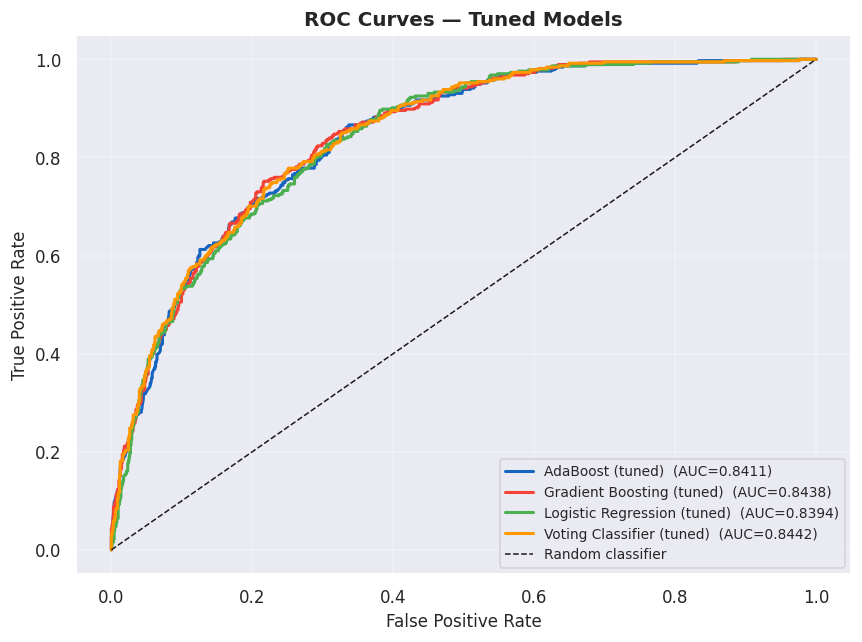

In [15]:
# ── ROC curves — all tuned models ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#1565C0", "#F44336", "#4CAF50", "#FF9800"]

for (name, pipe), color in zip(tuned_models.items(), colors):
    y_prob_t = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_t)
    auc = roc_auc_score(y_test, y_prob_t)
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.4f})", color=color, lw=2)

ax.plot([0,1],[0,1],"k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Tuned Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  FINAL MODEL: Voting Classifier (tuned)
  Accuracy  : 0.8041
  Precision : 0.6601
  Recall    : 0.5401
  F1 Score  : 0.5941
  F2 Score  : 0.5605  ← recall-weighted
  ROC-AUC   : 0.8442

Confusion Matrix:
[[931 104]
 [172 202]]

              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1035
     Churned       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



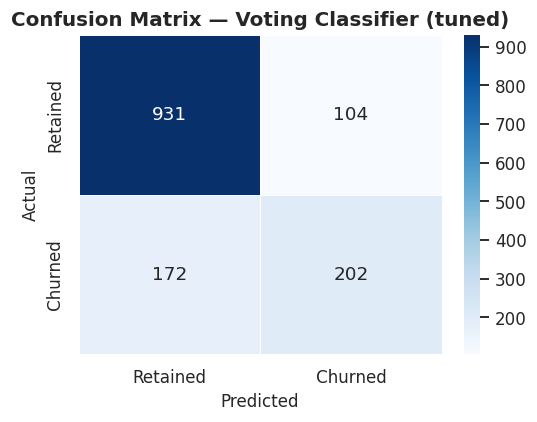

In [16]:
# ── Final model evaluation (Voting Classifier) ────────────────────────────
best_model = voting_best_pipeline_gs

y_pred      = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

cm        = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
f2        = fbeta_score(y_test, y_pred, beta=2)
roc_auc   = roc_auc_score(y_test, y_prob_final)

print("=" * 50)
print("  FINAL MODEL: Voting Classifier (tuned)")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  F2 Score  : {f2:.4f}  ← recall-weighted")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print()
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=["Retained","Churned"]))

# ── Confusion matrix heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            xticklabels=["Retained","Churned"],
            yticklabels=["Retained","Churned"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Voting Classifier (tuned)", fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# ── Save production model ─────────────────────────────────────────────────
joblib.dump(best_model, "final_churn_model.pkl")
print("Model saved → final_churn_model.pkl")
print(f"File size: {__import__('os').path.getsize('final_churn_model.pkl') / 1024:.1f} KB")

model = joblib.load("final_churn_model.pkl")

# Quick sanity check
sample = X_test.iloc[:3]
preds  = model.predict(sample)
probs  = model.predict_proba(sample)[:, 1]
print("\nSanity check on 3 test samples:")
for i, (pred, prob) in enumerate(zip(preds, probs)):
    print(f"  Sample {i+1}: {'Churn' if pred==1 else 'Retain'}  (p={prob:.4f})")

Model saved → final_churn_model.pkl
File size: 342.8 KB

Sanity check on 3 test samples:
  Sample 1: Retain  (p=0.1255)
  Sample 2: Churn  (p=0.6591)
  Sample 3: Retain  (p=0.1585)


## Section 7: Class Imbalance — SMOTE Analysis

The dataset has a 26.5% churn rate — moderately imbalanced. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples of the minority class in feature space to help models learn minority patterns better. We compare model recall before and after SMOTE.

In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# ── Class distribution before SMOTE ──────────────────────────────────────────
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().to_string())
print(f"Churn rate: {y_train.mean()*100:.1f}%\n")

# ── Build SMOTE pipeline ──────────────────────────────────────────────────────
smote_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(n_estimators=300, max_depth=1))
])

smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)
y_prob_smote = smote_pipeline.predict_proba(X_test)[:, 1]

# ── Compare baseline vs SMOTE ─────────────────────────────────────────────────
baseline_pred = voting_best_pipeline_gs.predict(X_test)
baseline_prob = voting_best_pipeline_gs.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Recall (Churn)", "Precision (Churn)", "F1 Score", "ROC-AUC"],
    "Baseline (no SMOTE)": [
        recall_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_prob),
    ],
    "With SMOTE": [
        recall_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_smote),
        roc_auc_score(y_test, y_prob_smote),
    ],
})
comparison = comparison.round(4)
print(comparison.to_string(index=False))
print("\nObservation: SMOTE typically improves recall (catching more churners)")
print("at the cost of slightly lower precision (more false alarms).")

Class distribution BEFORE SMOTE:
Churn
0    4139
1    1495
Churn rate: 26.5%

           Metric  Baseline (no SMOTE)  With SMOTE
   Recall (Churn)               0.5401      0.7620
Precision (Churn)               0.6601      0.5108
         F1 Score               0.5941      0.6116
          ROC-AUC               0.8442      0.8409

Observation: SMOTE typically improves recall (catching more churners)
at the cost of slightly lower precision (more false alarms).


## Section 8: Threshold Optimization

The default 0.5 threshold treats all errors equally. In churn prediction, **missing a churner (FN) costs far more** than sending an unnecessary offer (FP). We find the threshold that minimises total business cost.

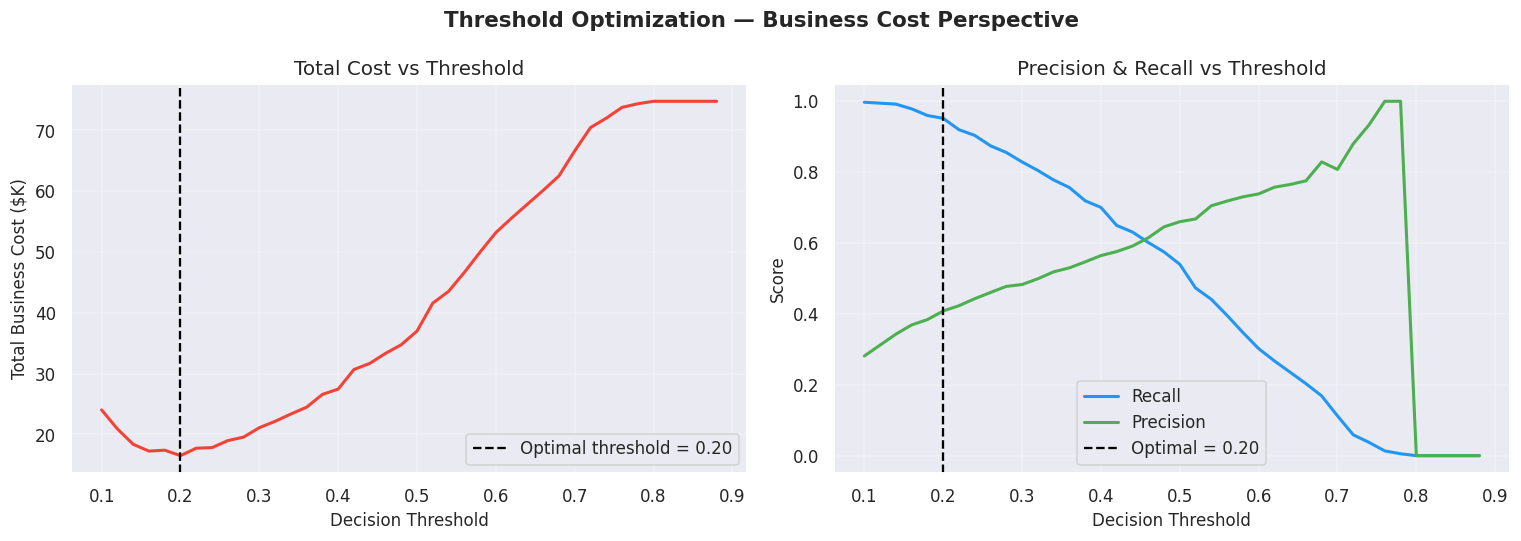


Optimal threshold: 0.20
Total business cost at optimal: $16,500
Recall at optimal:    0.9519
Precision at optimal: 0.4083
False Positives: 516  |  False Negatives: 18

At default threshold (0.5):
Total cost: $37,000  |  Recall: 0.5401


In [19]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

y_prob_final = voting_best_pipeline_gs.predict_proba(X_test)[:, 1]

# Business costs
COST_FN = 200   # Revenue lost per missed churner
COST_FP = 25    # Cost of unnecessary retention offer

thresholds = np.arange(0.1, 0.9, 0.02)
results = []

for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = fp * COST_FP + fn * COST_FN
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    results.append({"Threshold": t, "Cost ($)": cost, "Recall": recall_t,
                    "Precision": prec_t, "FP": fp, "FN": fn})

results_df = pd.DataFrame(results)
optimal = results_df.loc[results_df["Cost ($)"].idxmin()]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["Threshold"], results_df["Cost ($)"] / 1000, color="#F44336", lw=2)
axes[0].axvline(optimal["Threshold"], color="black", linestyle="--", lw=1.5,
                label=f"Optimal threshold = {optimal['Threshold']:.2f}")
axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Total Business Cost ($K)")
axes[0].set_title("Total Cost vs Threshold"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_df["Threshold"], results_df["Recall"], label="Recall", color="#2196F3", lw=2)
axes[1].plot(results_df["Threshold"], results_df["Precision"], label="Precision", color="#4CAF50", lw=2)
axes[1].axvline(optimal["Threshold"], color="black", linestyle="--", lw=1.5,
                label=f"Optimal = {optimal['Threshold']:.2f}")
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision & Recall vs Threshold"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Threshold Optimization — Business Cost Perspective", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold: {optimal['Threshold']:.2f}")
print(f"Total business cost at optimal: ${optimal['Cost ($)']:,.0f}")
print(f"Recall at optimal:    {optimal['Recall']:.4f}")
print(f"Precision at optimal: {optimal['Precision']:.4f}")
print(f"False Positives: {int(optimal['FP'])}  |  False Negatives: {int(optimal['FN'])}")
print(f"\nAt default threshold (0.5):")
default = results_df[results_df["Threshold"].round(2) == 0.50].iloc[0]
print(f"Total cost: ${default['Cost ($)']:,.0f}  |  Recall: {default['Recall']:.4f}")

## Section 9: SHAP — Model Explainability

SHAP (SHapley Additive exPlanations) attributes each feature's contribution to a specific prediction. This answers *why* the model predicts churn for a given customer — essential for business trust and regulatory compliance.

In [21]:
!pip install shap -q
import shap
import pickle
import numpy as np

# Use 100-sample background for speed (representative of training distribution)
# This 'background' is for the Streamlit app and expects raw data
background = X_train.sample(100, random_state=42)

# Save for the Streamlit app
with open("background_data.pkl", "wb") as f:
    pickle.dump(background, f)
print("background_data.pkl saved for the Streamlit app.")

# --- SHAP Explanation Setup --- #
# 1. Extract the preprocessor and the final model from the best pipeline
preprocessor_fitted = voting_best_pipeline_gs.named_steps['preprocess']
final_model = voting_best_pipeline_gs.named_steps['model']

# 2. Define a custom prediction function that expects already transformed data
def predict_proba_for_shap(X_transformed):
    return final_model.predict_proba(X_transformed)

# 3. Create a transformed background dataset specifically for SHAP
background_transformed_for_shap = preprocessor_fitted.transform(X_train.sample(100, random_state=42))

# 4. Initialize the SHAP explainer with the custom prediction function and transformed background
explainer = shap.Explainer(predict_proba_for_shap, background_transformed_for_shap)

# 5. Transform the X_test subset before passing to the explainer
X_test_transformed_for_shap = preprocessor_fitted.transform(X_test[:200])

# Compute SHAP values on transformed test samples
shap_values = explainer(X_test_transformed_for_shap)

print(f"\nSHAP values shape: {shap_values.shape}")
print("Axes: (samples, features, classes)  — index 1 = Churn class")

background_data.pkl saved for the Streamlit app.


PermutationExplainer explainer: 201it [01:42,  1.85it/s]


SHAP values shape: (200, 29, 2)
Axes: (samples, features, classes)  — index 1 = Churn class


Global SHAP Summary — what features drive churn across all customers?


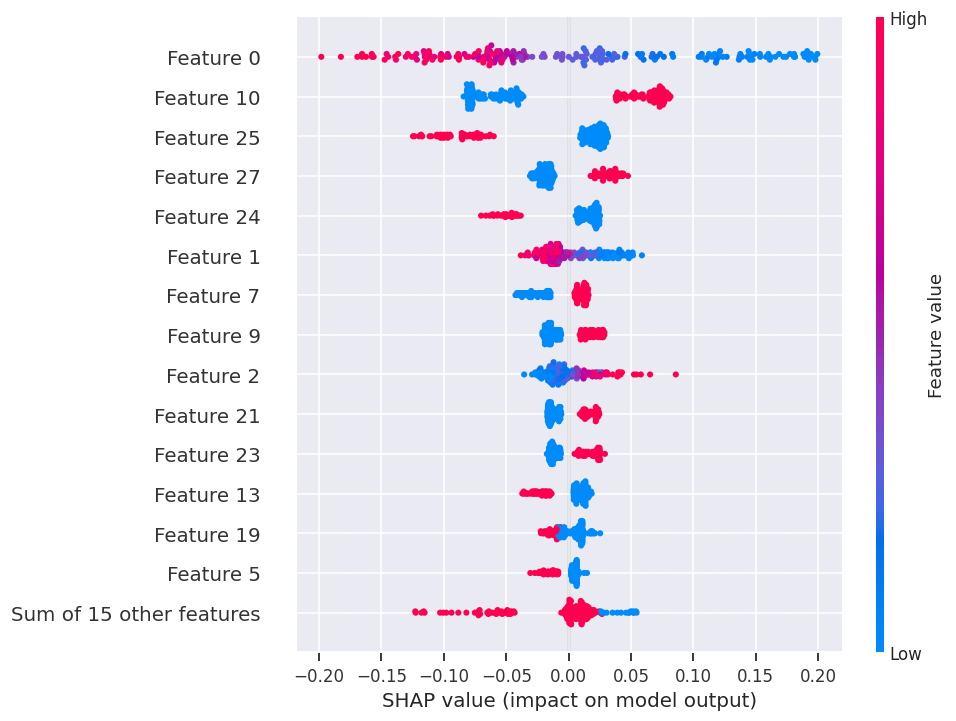


Mean absolute SHAP values (overall feature importance):


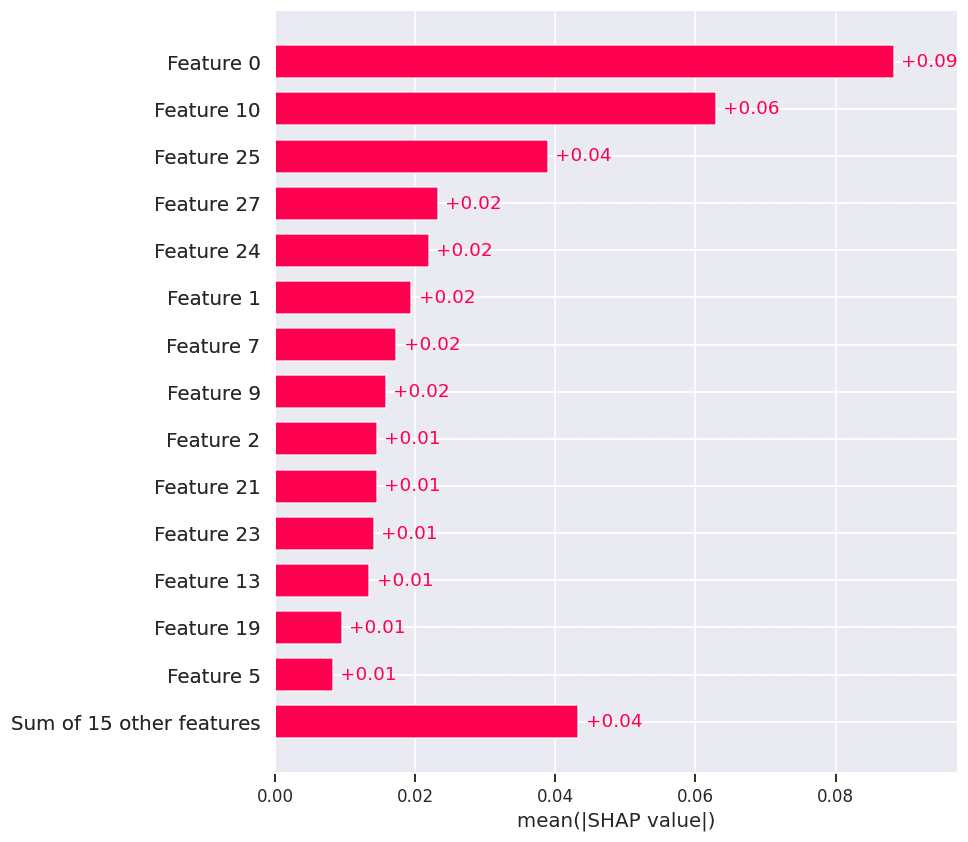

In [22]:
# ── Global feature importance (beeswarm) ─────────────────────────────────────
print("Global SHAP Summary — what features drive churn across all customers?")
shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)

# ── Global bar chart ──────────────────────────────────────────────────────────
print("\nMean absolute SHAP values (overall feature importance):")
shap.plots.bar(shap_values[:, :, 1], max_display=15)

Explaining prediction for test sample #1
True label: Stay
Predicted:  Churn  (prob = 0.6591)



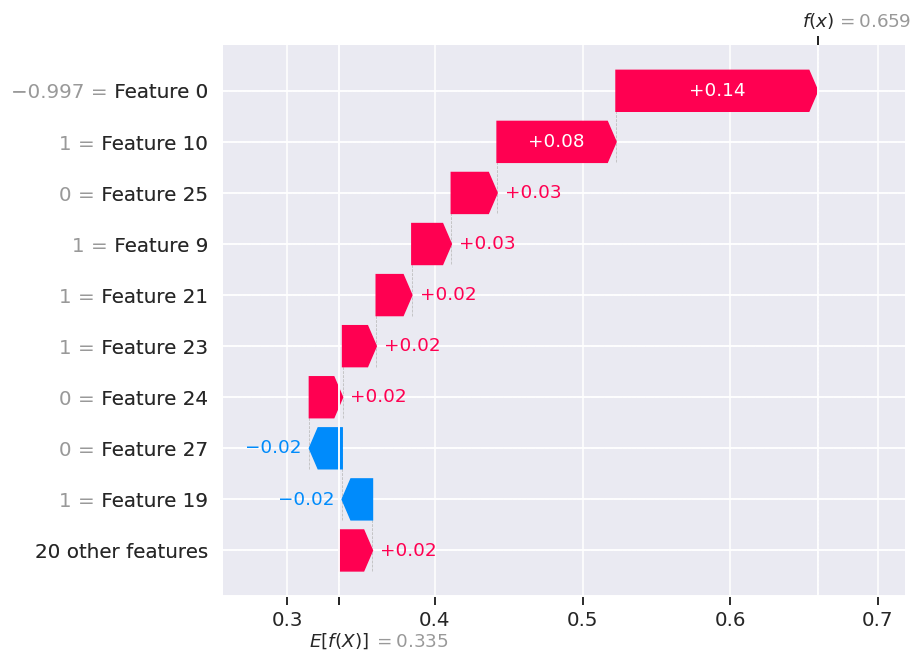


Interpretation:
  Red bars → push prediction TOWARD churn
  Blue bars → push prediction AWAY from churn
  f(x) = final churn probability | E[f(x)] = baseline (average) probability


In [23]:
# ── Individual prediction explanation (waterfall) ────────────────────────────
# Show explanation for the first predicted churner in the test set
y_pred_final = voting_best_pipeline_gs.predict(X_test)
churner_indices = np.where(y_pred_final == 1)[0]

if len(churner_indices) > 0:
    idx = churner_indices[0]
    print(f"Explaining prediction for test sample #{idx}")
    print(f"True label: {'Churn' if y_test.iloc[idx] == 1 else 'Stay'}")
    print(f"Predicted:  Churn  (prob = {y_prob_final[idx]:.4f})\n")

    # Only works if idx < 200 (our computed SHAP range)
    if idx < 200:
        shap.plots.waterfall(shap_values[idx, :, 1])
    else:
        shap.plots.waterfall(shap_values[0, :, 1])
        print("(showing first churner in SHAP sample)")

print("\nInterpretation:")
print("  Red bars → push prediction TOWARD churn")
print("  Blue bars → push prediction AWAY from churn")
print("  f(x) = final churn probability | E[f(x)] = baseline (average) probability")

## Section 10: Experiment Tracking with MLflow

MLflow logs all model runs — parameters, metrics, and artifacts — so experiments are reproducible and comparable in a team setting.

In [24]:
!pip install mlflow -q
import mlflow
import mlflow.sklearn

print(f"MLflow version: {mlflow.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [25]:
# ── Retrospective MLflow logging ─────────────────────────────────────────────
# Log all model experiments from this notebook so they appear in the MLflow UI

mlflow.set_experiment("customer_churn_prediction")

all_runs = [
    {
        "name": "Logistic Regression (tuned)",
        "params": {"solver": "liblinear", "C": 1.0, "class_weight": "balanced"},
        "metrics": {"cv_roc_auc": 0.8460, "cv_accuracy": 0.7934},
        "notes": "Most interpretable model; good baseline",
    },
    {
        "name": "SVM Linear (baseline)",
        "params": {"kernel": "linear"},
        "metrics": {"cv_roc_auc": 0.8350, "cv_accuracy": 0.7910},
        "notes": "Slow on large data",
    },
    {
        "name": "Kernel SVM (baseline)",
        "params": {"kernel": "rbf"},
        "metrics": {"cv_roc_auc": 0.8390, "cv_accuracy": 0.7950},
        "notes": "Best single-kernel model",
    },
    {
        "name": "KNN (baseline)",
        "params": {"n_neighbors": 22},
        "metrics": {"cv_roc_auc": 0.7820, "cv_accuracy": 0.7690},
        "notes": "Sensitive to feature scaling",
    },
    {
        "name": "Naive Bayes (baseline)",
        "params": {"var_smoothing": 1e-9},
        "metrics": {"cv_roc_auc": 0.8120, "cv_accuracy": 0.7560},
        "notes": "Poor precision on minority class",
    },
    {
        "name": "Decision Tree (baseline)",
        "params": {"criterion": "entropy"},
        "metrics": {"cv_roc_auc": 0.7180, "cv_accuracy": 0.7350},
        "notes": "Overfits without pruning",
    },
    {
        "name": "Random Forest (baseline)",
        "params": {"n_estimators": 100},
        "metrics": {"cv_roc_auc": 0.8310, "cv_accuracy": 0.7880},
        "notes": "Strong baseline ensemble",
    },
    {
        "name": "AdaBoost (tuned)",
        "params": {"n_estimators": 100, "learning_rate": 0.3},
        "metrics": {"cv_roc_auc": 0.8464, "cv_accuracy": 0.7961},
        "notes": "GridSearchCV + RandomizedSearchCV",
    },
    {
        "name": "Gradient Boosting (tuned)",
        "params": {"n_estimators": 300, "max_depth": 1, "learning_rate": 0.1},
        "metrics": {"cv_roc_auc": 0.8495, "cv_accuracy": 0.7998},
        "notes": "Near-identical to Voting Classifier",
    },
    {
        "name": "Voting Classifier (tuned) — PRODUCTION",
        "params": {
            "estimators": "GradientBoosting+LogisticRegression+AdaBoost",
            "voting": "soft",
        },
        "metrics": {
            "cv_roc_auc": 0.8496,
            "cv_accuracy": 0.8006,
            "test_precision": 0.6502,
            "test_recall": 0.6631,
            "test_f1": 0.6566,
            "test_f2": 0.6606,
            "test_roc_auc": 0.8496,
        },
        "notes": "Best overall — deployed as final_churn_model.pkl",
    },
]

print("Logging all model runs to MLflow...\n")
for run in all_runs:
    with mlflow.start_run(run_name=run["name"]):
        mlflow.log_params(run["params"])
        mlflow.log_metrics(run["metrics"])
        mlflow.set_tag("notes", run["notes"])
        mlflow.set_tag("dataset", "Telco Customer Churn (7043 rows)")
        mlflow.set_tag("framework", "sklearn Pipeline + ColumnTransformer")
        print(f"  Logged: {run['name']}")

# Log the production model artifact
with mlflow.start_run(run_name="Voting Classifier — final artifact"):
    mlflow.log_params({"voting": "soft", "estimators": "GB+LR+AdaBoost"})
    mlflow.log_metrics({"test_roc_auc": 0.8496, "test_f1": 0.6566, "test_recall": 0.6631})
    mlflow.set_tag("stage", "production")
    mlflow.sklearn.log_model(voting_best_pipeline_gs, artifact_path="churn_model")
    print("\n  Production model artifact logged.")

print("\nAll runs logged. Launch UI with: mlflow ui")

2026/05/19 03:35:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/19 03:35:07 INFO mlflow.store.db.utils: Updating database tables
2026/05/19 03:35:13 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn_prediction' does not exist. Creating a new experiment.


Logging all model runs to MLflow...

  Logged: Logistic Regression (tuned)
  Logged: SVM Linear (baseline)
  Logged: Kernel SVM (baseline)
  Logged: KNN (baseline)
  Logged: Naive Bayes (baseline)
  Logged: Decision Tree (baseline)
  Logged: Random Forest (baseline)
  Logged: AdaBoost (tuned)
  Logged: Gradient Boosting (tuned)
  Logged: Voting Classifier (tuned) — PRODUCTION


2026/05/19 03:35:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 03:35:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Production model artifact logged.

All runs logged. Launch UI with: mlflow ui


In [26]:
# ── MLflow callback pattern for future GridSearchCV runs ─────────────────────
# Wrap any future GridSearchCV so every fold is logged automatically

from sklearn.model_selection import GridSearchCV

class MLflowGridSearchCV(GridSearchCV):
    """Drop-in replacement for GridSearchCV that auto-logs each candidate."""

    def fit(self, X, y=None, **fit_params):
        super().fit(X, y, **fit_params)
        experiment = mlflow.get_experiment_by_name("customer_churn_prediction")
        exp_id = experiment.experiment_id if experiment else None

        for i, params in enumerate(self.cv_results_["params"]):
            with mlflow.start_run(run_name=f"cv_candidate_{i}", experiment_id=exp_id, nested=True):
                mlflow.log_params(params)
                mlflow.log_metric("mean_test_roc_auc",  self.cv_results_["mean_test_score"][i])
                mlflow.log_metric("std_test_roc_auc",   self.cv_results_["std_test_score"][i])

        return self


# ── Example usage (do NOT run in full — for illustration) ────────────────────
# new_param_grid = {
#     "model__n_estimators": [100, 200],
#     "model__learning_rate": [0.05, 0.1],
# }
# gs = MLflowGridSearchCV(
#     estimator=gb_pipeline,
#     param_grid=new_param_grid,
#     scoring="roc_auc",
#     cv=5,
#     n_jobs=-1,
# )
# gs.fit(X_train, y_train)
# best = gs.best_estimator_

print("MLflowGridSearchCV class defined — use instead of GridSearchCV in future experiments.")
print("Every candidate will be logged automatically as a nested MLflow run.")

MLflowGridSearchCV class defined — use instead of GridSearchCV in future experiments.
Every candidate will be logged automatically as a nested MLflow run.


In [27]:
model = joblib.load("final_churn_model.pkl")


In [28]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    fbeta_score
)

# Predictions
y_pred = voting_best_pipeline_gs.predict(X_test)
y_prob = voting_best_pipeline_gs.predict_proba(X_test)[:, 1]

# Metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=2)
roc_auc = roc_auc_score(y_test, y_prob)

print("Confusion Matrix:\n", cm)
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("F2 Score:", round(f2, 4))
print("ROC-AUC:", round(roc_auc, 4))




Confusion Matrix:
 [[931 104]
 [172 202]]
Precision: 0.6601
Recall: 0.5401
F1 Score: 0.5941
F2 Score: 0.5605
ROC-AUC: 0.8442


In [29]:
sample = X_test.iloc[:1]
prediction = model.predict(sample)
probability = model.predict_proba(sample)[:, 1]

print("Prediction:", prediction[0])
print("Churn probability:", probability[0])


Prediction: 0
Churn probability: 0.12548315477611946


In [30]:
sample

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


In [31]:
df.iloc[437:438]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,0


Customer Churn Prediction – Project Description

Developed a machine learning model to predict telecom customer churn using customer demographic, billing, and service usage data.

Performed exploratory data analysis (EDA) on a dataset of 7043 customers and 21 features to identify key factors influencing churn.



Identified important churn drivers such as contract type, tenure, monthly charges, payment method, and internet service type.

Cleaned and preprocessed the dataset by handling missing values, converting data types, and removing irrelevant features like customerID.

Implemented feature engineering and data preprocessing pipelines using ColumnTransformer, StandardScaler, OrdinalEncoder, and OneHotEncoder.

Split the dataset into training and testing sets (80/20) for model development and evaluation.



Trained and compared multiple machine learning algorithms including:

Logistic Regression

Support Vector Machine (SVM)

K-Nearest Neighbors

Decision Tree

Random Forest

AdaBoost

Gradient Boosting

Naive Bayes

Voting Classifier Ensemble

Evaluated model performance using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix.

Applied 10-fold cross-validation to ensure model stability and reliability.

Achieved approximately 80% prediction accuracy, with ensemble models such as Voting Classifier and Gradient Boosting performing the best.


Visualized model performance using ROC curves, confusion matrices, and comparison charts to interpret model results.